***Note***:- If you are working Locally using anaconda, please uncomment the following code and execute it.
Use the version as per your python version.


In [37]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib
!pip install pandas

## Use yfinance to Extract Stock Data


In [51]:
import yfinance as yf
tesla_data=yf.Ticker('TSLA')
tesla_data=tesla_data.history(period="max")

In [52]:
tesla_data.reset_index(inplace=True)
print(tesla_data.head())

                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


## Use Webscraping to Extract Tesla Revenue Data


In [53]:
import requests
from bs4 import BeautifulSoup
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data=requests.get(url).text

In [54]:
import pandas as pd
soup = BeautifulSoup(html_data,'html.parser')
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])

In [55]:
for row in soup.find('tbody').find_all('tr'):
    cols = row.find_all('td')
    date = cols[0].text.strip()
    revenue = cols[1].text.strip()

    tesla_revenue = pd.concat([
        tesla_revenue,
        pd.DataFrame({"Date": [date], "Revenue": [revenue]})
    ], ignore_index=True)

In [56]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\\$',"",regex=True)

In [57]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [58]:
print(tesla_revenue.tail)

<bound method NDFrame.tail of     Date Revenue
0   2021   53823
1   2020   31536
2   2019   24578
3   2018   21461
4   2017   11759
5   2016    7000
6   2015    4046
7   2014    3198
8   2013    2013
9   2012     413
10  2011     204
11  2010     117
12  2009     112>


## Use yfinance to Extract Stock Data


In [59]:
import yfinance as yf
gamestop_data=yf.Ticker('GME')
game_df=gamestop_data.history(period="max")

In [60]:
game_df.reset_index(inplace=True)

## Use Webscraping to Extract GME Revenue Data


In [61]:
import requests
from bs4 import BeautifulSoup
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data_2=requests.get(url).text

In [62]:
import pandas as pd
soup = BeautifulSoup(html_data,'html.parser')
gme_revenue=pd.DataFrame(columns=["Date","Revenue"])

In [63]:
for row in soup.find('tbody').find_all('tr'):
    cols = row.find_all('td')
    date = cols[0].text.strip()
    revenue = cols[1].text.strip()

    gme_revenue = pd.concat([
        gme_revenue,
        pd.DataFrame({"Date": [date], "Revenue": [revenue]})
    ], ignore_index=True)

In [64]:
gme_revenue["Revenue"]=gme_revenue["Revenue"].str.replace('\\$|,',"",regex=True)

In [65]:
gme_revenue.tail

<bound method NDFrame.tail of     Date Revenue
0   2021   53823
1   2020   31536
2   2019   24578
3   2018   21461
4   2017   11759
5   2016    7000
6   2015    4046
7   2014    3198
8   2013    2013
9   2012     413
10  2011     204
11  2010     117
12  2009     112>

## Plot Tesla Stock Graph


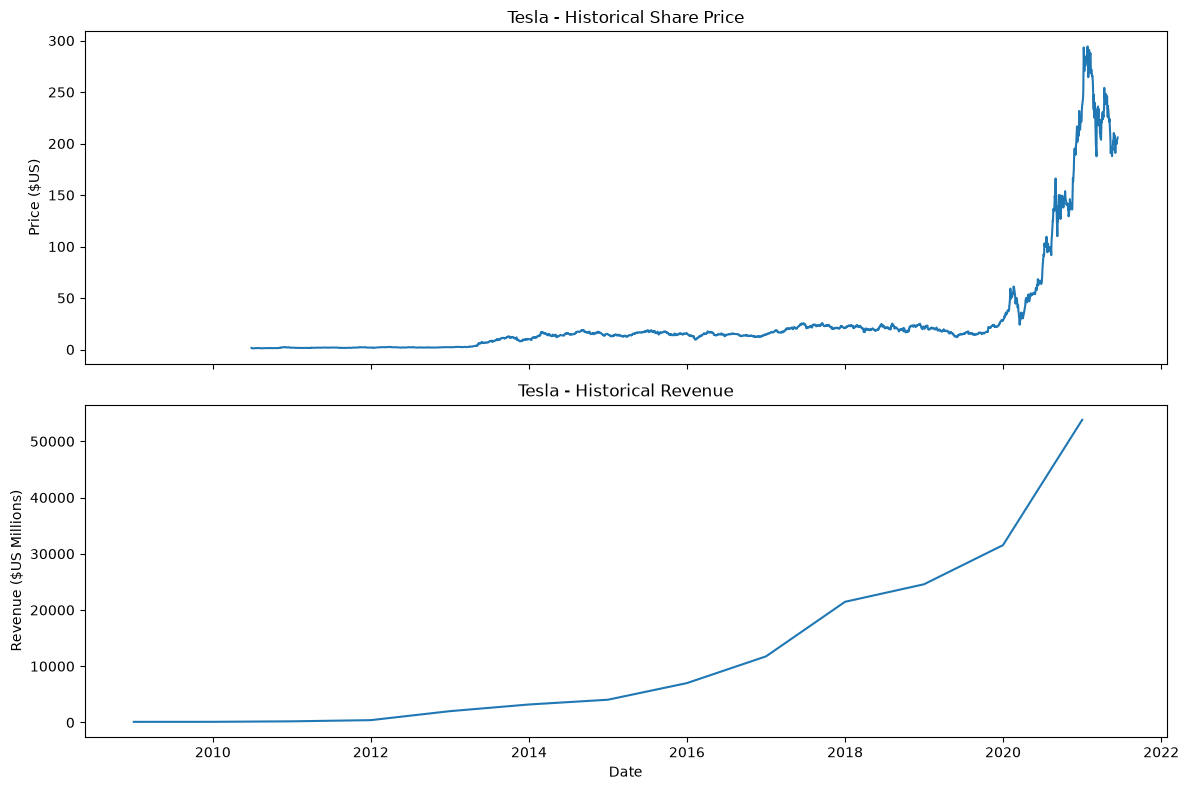

In [66]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(
        pd.to_datetime(stock_data_specific.Date),
        stock_data_specific.Close.astype("float"),
        label="Share Price"
    )
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(
        pd.to_datetime(revenue_data_specific.Date),
        revenue_data_specific.Revenue.astype("float"),
        label="Revenue"
    )
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

make_graph(tesla_data, tesla_revenue, 'Tesla')

## Plot GameStop Stock Graph


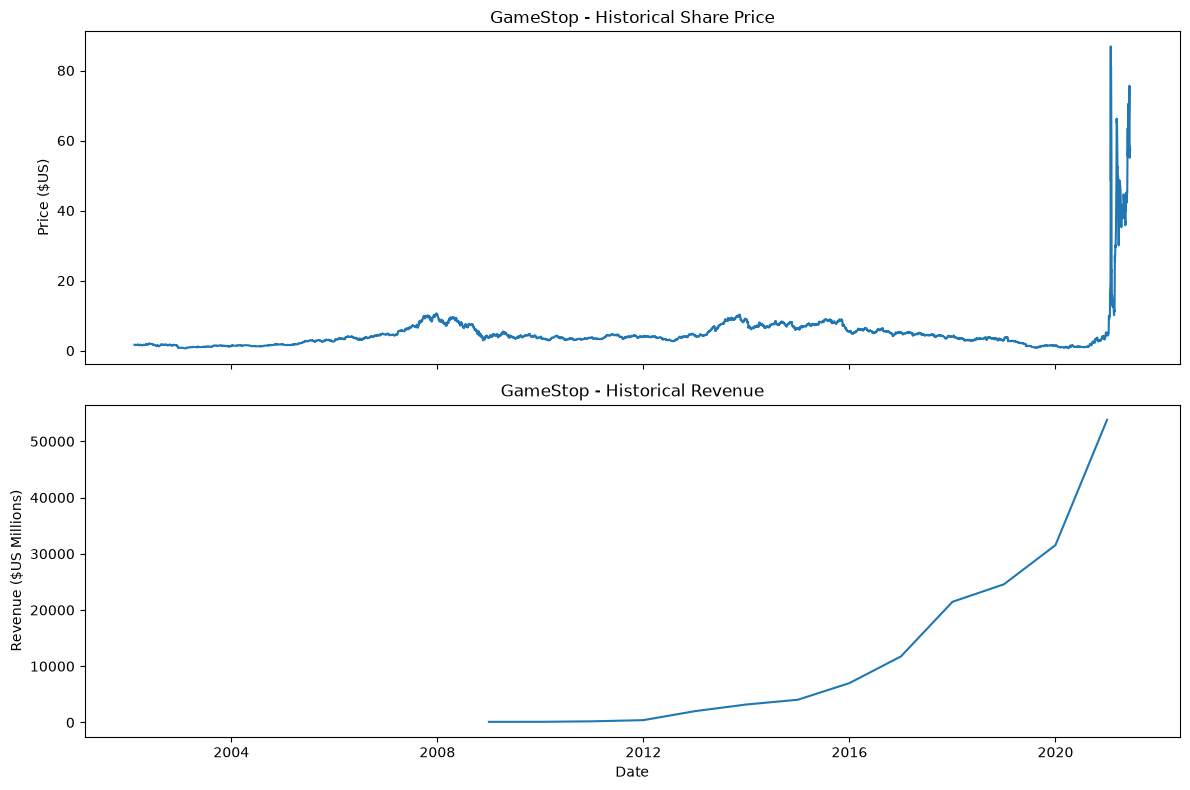

In [99]:
make_graph(game_df, gme_revenue, 'GameStop')